In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [4]:
data = pd.read_csv(r'C:\Users\Usuario\Downloads\LEGODECISIONTREE.csv').drop(columns = ['Unnamed: 0'])

In [5]:
data

,Piezas,Minifiguras,Precio
0,250,2,24.99
1,750,4,59.99
2,1500,6,129.99
3,450,3,34.99
4,1200,5,89.99
5,350,1,29.99
6,1800,7,159.99


### Modelo"

In [6]:
X = data[['Piezas', 'Minifiguras']]
y = data['Precio']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

In [8]:
X_test

,Piezas,Minifiguras
0,250,2
1,750,4


In [9]:
modelo = DecisionTreeRegressor(
    max_depth = 10,
    random_state = 42
)
modelo.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
y_pred = modelo.predict(X_test)

In [11]:
y_test

0    24.99
1    59.99
Name: Precio, dtype: float64

### Nuevo lego

In [12]:
nuevo_lego = pd.DataFrame({
    'Piezas': [800],
    'Minifiguras': [2]
})

In [13]:
prediccion_nuevo = modelo.predict(nuevo_lego)
print(prediccion_nuevo)

[29.99]


### Evaluar Modelo

In [14]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print(f'MSE: {mse}, MAE: {mae}, r2: {r2}')

MSE: 325.0, MAE: 15.0, r2: -0.06122448979591821


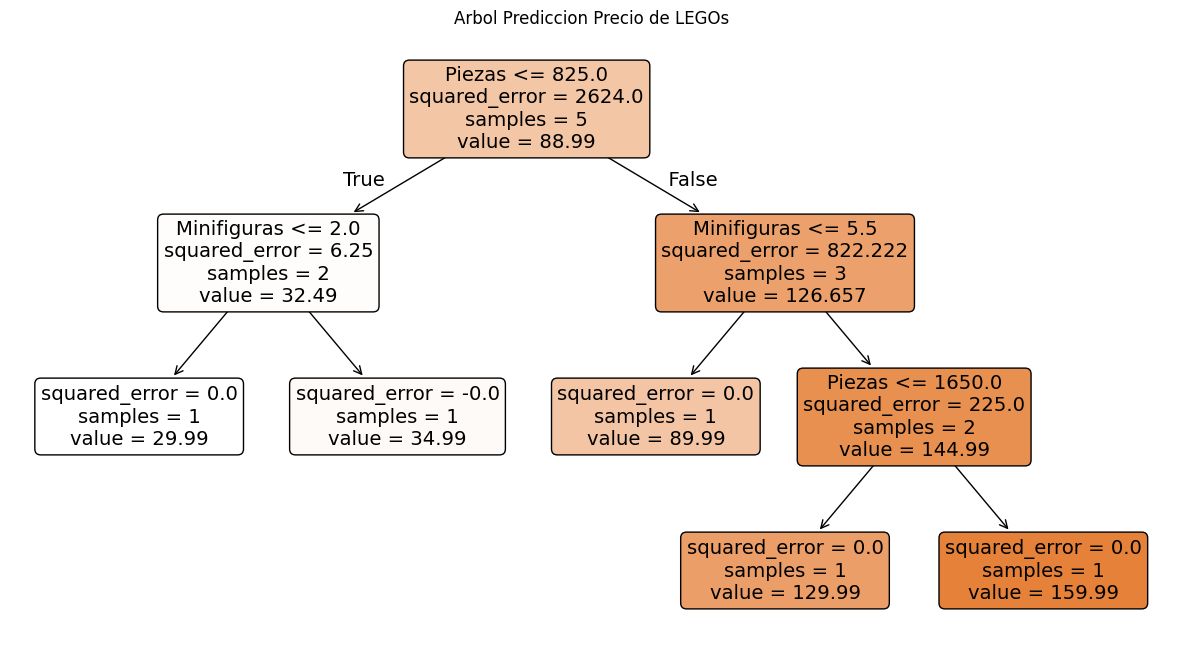

In [16]:
plt.figure(figsize = (15, 8))
plot_tree(modelo,
          feature_names = ['Piezas', 'Minifiguras'],
          filled = True,
          rounded = True
         )
plt.title('Arbol Prediccion Precio de LEGOs')
plt.show()